In [1]:
import pandas as pd
import numpy as np

# Load data
df = pd.read_excel(
    "/Users/krishnakumarjena/Downloads/Projects/Credit Risk/merged_customer_data.xlsx"
)

# Dataset shape
print("Dataset Shape:", df.shape)

# Data types
print("\nData Types:")
print(df.dtypes)

# Missing values
missing_summary = pd.DataFrame({
    "Missing_Count": df.isnull().sum(),
    "Missing_%": df.isnull().mean() * 100
})

missing_summary = missing_summary.sort_values(
    "Missing_%",
    ascending=False
)

print("\nMissing Value Summary:")
print(missing_summary)

# Target distribution
target = "Default_y"

print("\nTarget Distribution:")
print(df[target].value_counts())

print("\nTarget Distribution (%):")
print(
    df[target]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

# Numerical summary
numeric_cols = df.select_dtypes(
    include=np.number
).columns

print("\nNumerical Variable Summary:")
print(df[numeric_cols].describe().T)

# Categorical variables
categorical_cols = df.select_dtypes(
    include="object"
).columns

print("\nCategorical Variables:")
print(categorical_cols.tolist())

# Category distributions
for col in categorical_cols:
    print(f"\n{col}:")
    print(df[col].value_counts(dropna=False))

Dataset Shape: (100, 34)

Data Types:
Customer_ID                               int64
Age                                       int64
Income_INR                                int64
Employment_Years                          int64
Marital_Status                              str
Education_Level                             str
Credit_History_Length                     int64
Outstanding_Loans                         int64
Loan_Amount                               int64
Loan_Tenure_Months                        int64
Savings_Account_Balance                   int64
Checking_Account_Balance                  int64
Pay_History                                 str
Delinquency_12M                           int64
Credit_Card_Utilization                 float64
Behavior_Spending_Score                   int64
Behavior_Repayment_Score                  int64
Default_x                                 int64
No_of_Open_Accounts                       int64
No_of_Closed_Accounts                     int64
To

/var/folders/pk/_sj8msnd6058p2323ky_h2280000gn/T/ipykernel_49225/4210096082.py:53: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(


Step 2 — Data Quality Check

In [2]:
# Check duplicate rows
print("Duplicate Rows:", df.duplicated().sum())

# Check duplicate customers
print("Duplicate Customer IDs:", df["Customer_ID"].duplicated().sum())

# Check missing values
missing_summary = pd.DataFrame({
    "Missing_Count": df.isnull().sum(),
    "Missing_%": df.isnull().mean() * 100
})

missing_summary = missing_summary[
    missing_summary["Missing_Count"] > 0
].sort_values(
    "Missing_%",
    ascending=False
)

print("\nMissing Values:")
print(missing_summary)

# Check unique values
unique_summary = pd.DataFrame({
    "Unique_Count": df.nunique()
}).sort_values(
    "Unique_Count"
)

print("\nUnique Values:")
print(unique_summary)

# Check target values
print("\nTarget Values:")
print(df["Default_y"].value_counts(dropna=False))

# Check invalid target values
print("\nInvalid Target Values:")
print(
    df.loc[
        ~df["Default_y"].isin([0, 1]),
        "Default_y"
    ].unique()
)

Duplicate Rows: 0
Duplicate Customer IDs: 0

Missing Values:
Empty DataFrame
Columns: [Missing_Count, Missing_%]
Index: []

Unique Values:
                                      Unique_Count
Default_y                                        2
Default_x                                        2
DPD_60                                           2
DPD_90                                           2
Marital_Status                                   3
DPD_30                                           3
Pay_History                                      3
Worst_Current_Status                             4
Education_Level                                  4
Delinquency_12M                                  5
No_of_Inquiries_6M                               5
Loan_Tenure_Months                               6
No_of_Closed_Accounts                            8
Outstanding_Loans                               10
No_of_Inquiries_12M                             10
No_of_Open_Accounts                          

Step 3: Missing Value Treatment

In [3]:
# Check missing values
missing_summary = pd.DataFrame({
    "Missing_Count": df.isnull().sum(),
    "Missing_%": df.isnull().mean() * 100
})

missing_summary = missing_summary[
    missing_summary["Missing_Count"] > 0
].sort_values(
    "Missing_%",
    ascending=False
)

print("Missing Value Summary:")
print(missing_summary)

Missing Value Summary:
Empty DataFrame
Columns: [Missing_Count, Missing_%]
Index: []


In [4]:
# Identify variable types
numeric_cols = df.select_dtypes(
    include=np.number
).columns.tolist()

categorical_cols = df.select_dtypes(
    include="object"
).columns.tolist()

print("Numerical Variables:")
print(numeric_cols)

print("\nCategorical Variables:")
print(categorical_cols)

Numerical Variables:
['Customer_ID', 'Age', 'Income_INR', 'Employment_Years', 'Credit_History_Length', 'Outstanding_Loans', 'Loan_Amount', 'Loan_Tenure_Months', 'Savings_Account_Balance', 'Checking_Account_Balance', 'Delinquency_12M', 'Credit_Card_Utilization', 'Behavior_Spending_Score', 'Behavior_Repayment_Score', 'Default_x', 'No_of_Open_Accounts', 'No_of_Closed_Accounts', 'Total_Credit_Limit', 'Total_Current_Balance', 'Credit_Utilization_Ratio', 'No_of_Inquiries_6M', 'No_of_Inquiries_12M', 'DPD_30', 'DPD_60', 'DPD_90', 'Worst_Current_Status', 'Months_Since_Most_Recent_Delinquency', 'Max_Credit_Exposure', 'Oldest_Trade_Open_Months', 'Newest_Trade_Open_Months', 'Default_y']

Categorical Variables:
['Marital_Status', 'Education_Level', 'Pay_History']


/var/folders/pk/_sj8msnd6058p2323ky_h2280000gn/T/ipykernel_49225/2132490023.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(


In [5]:
# Numerical missing values
numeric_missing = df[numeric_cols].isnull().sum()

print("Numerical Missing Values:")
print(
    numeric_missing[numeric_missing > 0]
)

# Categorical missing values
categorical_missing = df[categorical_cols].isnull().sum()

print("\nCategorical Missing Values:")
print(
    categorical_missing[categorical_missing > 0]
)

Numerical Missing Values:
Series([], dtype: int64)

Categorical Missing Values:
Series([], dtype: int64)


In [6]:
# Treat missing categorical values as a separate category
for col in categorical_cols:
    df[col] = df[col].fillna("Missing")

print("Categorical missing values handled.")

Categorical missing values handled.


In [7]:
# Final missing value check
remaining_missing = df.isnull().sum()

remaining_missing = remaining_missing[
    remaining_missing > 0
].sort_values(
    ascending=False
)

print("Remaining Missing Values:")
print(remaining_missing)

Remaining Missing Values:
Series([], dtype: int64)


Step 4 — Light EDA

Numerical Summary:
                                      count          mean            std  \
Customer_ID                           100.0  5.050000e+01      29.011492   
Age                                   100.0  4.203000e+01      12.919686   
Income_INR                            100.0  1.393589e+06  740636.861367   
Employment_Years                      100.0  1.422000e+01       9.392217   
Credit_History_Length                 100.0  9.980000e+00       5.790937   
Outstanding_Loans                     100.0  4.800000e+00       2.916342   
Loan_Amount                           100.0  9.783073e+05  528227.901659   
Loan_Tenure_Months                    100.0  4.104000e+01      20.832143   
Savings_Account_Balance               100.0  5.158902e+05  312051.470131   
Checking_Account_Balance              100.0  2.509240e+05  156171.097222   
Delinquency_12M                       100.0  2.030000e+00       1.493792   
Credit_Card_Utilization               100.0  4.863000e-01       0.278

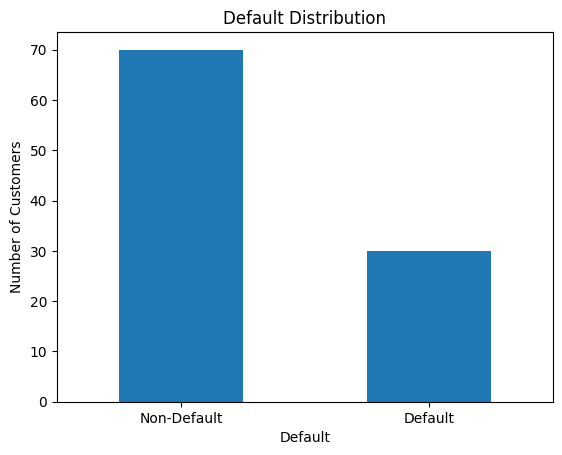

In [8]:
import matplotlib.pyplot as plt

# Numerical summary
numeric_cols = df.select_dtypes(
    include=np.number
).columns

print("Numerical Summary:")
print(df[numeric_cols].describe().T)

# Target distribution
target_rate = df["Default_y"].mean()

print("\nDefault Rate:", round(target_rate * 100, 2), "%")

# Target counts
print("\nTarget Counts:")
print(df["Default_y"].value_counts())

# Default rate by education
print("\nDefault Rate by Education:")
print(
    df.groupby("Education_Level")["Default_y"]
    .mean()
    .sort_values(ascending=False)
)

# Default rate by marital status
print("\nDefault Rate by Marital Status:")
print(
    df.groupby("Marital_Status")["Default_y"]
    .mean()
    .sort_values(ascending=False)
)

# Default rate by pay history
print("\nDefault Rate by Pay History:")
print(
    df.groupby("Pay_History")["Default_y"]
    .mean()
    .sort_values(ascending=False)
)

# Target distribution plot
df["Default_y"].value_counts().sort_index().plot(
    kind="bar"
)

plt.title("Default Distribution")
plt.xlabel("Default")
plt.ylabel("Number of Customers")
plt.xticks(
    ticks=[0, 1],
    labels=["Non-Default", "Default"],
    rotation=0
)
plt.show()

In [9]:
from sklearn.model_selection import train_test_split

# Define target
target = "Default_y"

# Remove non-predictor columns
exclude_cols = [
    "Customer_ID",
    "Default_x",
    "Default_y"
]

X = df.drop(columns=exclude_cols)
y = df[target]

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

# Check split
print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

# Check default rate
print("\nTraining Default Rate:")
print(round(y_train.mean() * 100, 2), "%")

print("\nTesting Default Rate:")
print(round(y_test.mean() * 100, 2), "%")

Training Shape: (70, 31)
Testing Shape: (30, 31)

Training Default Rate:
30.0 %

Testing Default Rate:
30.0 %


In [10]:
import pandas as pd
import numpy as np

# Copy training data
train_data = X_train.copy()
train_data[target] = y_train

# Identify variables
numeric_cols = train_data.select_dtypes(
    include=np.number
).columns.drop(target).tolist()

categorical_cols = train_data.select_dtypes(
    include="object"
).columns.tolist()

# Create binned dataset
binned_train = train_data.copy()

# Bin numerical variables
for col in numeric_cols:
    try:
        binned_train[col] = pd.qcut(
            train_data[col],
            q=5,
            duplicates="drop"
        )
    except:
        pass

# Keep categorical variables as categories
for col in categorical_cols:
    binned_train[col] = train_data[col].astype(str)

# Display bin counts
for col in numeric_cols:
    print(f"\n{col}:")
    print(binned_train[col].value_counts().sort_index())

# Display categorical counts
for col in categorical_cols:
    print(f"\n{col}:")
    print(binned_train[col].value_counts())


Age:
Age
(21.999, 31.0]    15
(31.0, 41.0]      14
(41.0, 48.4]      13
(48.4, 58.2]      14
(58.2, 64.0]      14
Name: count, dtype: int64

Income_INR:
Income_INR
(221958.999, 534930.4]    14
(534930.4, 1252803.8]     14
(1252803.8, 1649941.6]    14
(1649941.6, 2157885.2]    14
(2157885.2, 2498816.0]    14
Name: count, dtype: int64

Employment_Years:
Employment_Years
(-0.001, 3.0]    15
(3.0, 14.2]      13
(14.2, 18.0]     16
(18.0, 24.0]     13
(24.0, 29.0]     13
Name: count, dtype: int64

Credit_History_Length:
Credit_History_Length
(0.999, 4.0]    19
(4.0, 7.0]      10
(7.0, 12.0]     19
(12.0, 16.2]     8
(16.2, 19.0]    14
Name: count, dtype: int64

Outstanding_Loans:
Outstanding_Loans
(-0.001, 2.0]    18
(2.0, 4.6]       10
(4.6, 6.0]       17
(6.0, 8.0]       13
(8.0, 9.0]       12
Name: count, dtype: int64

Loan_Amount:
Loan_Amount
(51251.999, 586694.2]     14
(586694.2, 860432.6]      14
(860432.6, 1146560.2]     14
(1146560.2, 1422810.0]    14
(1422810.0, 1993327.0]    14


/var/folders/pk/_sj8msnd6058p2323ky_h2280000gn/T/ipykernel_49225/2567094390.py:13: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = train_data.select_dtypes(


In [11]:
# Calculate WoE
def calculate_woe(data, variable, target):
    temp = data[[variable, target]].copy()

    # Create bin summary
    summary = temp.groupby(
        variable,
        observed=False
    )[target].agg(
        ["count", "sum"]
    )

    # Calculate non-defaults
    summary["non_default"] = (
        summary["count"] - summary["sum"]
    )

    # Calculate distributions
    summary["default_dist"] = (
        summary["sum"] /
        summary["sum"].sum()
    )

    summary["non_default_dist"] = (
        summary["non_default"] /
        summary["non_default"].sum()
    )

    # Calculate WoE
    summary["WoE"] = np.log(
        summary["non_default_dist"] /
        summary["default_dist"]
    )

    return summary


# Store WoE results
woe_results = {}

# Numerical variables
for col in numeric_cols:
    woe_results[col] = calculate_woe(
        binned_train,
        col,
        target
    )

# Categorical variables
for col in categorical_cols:
    woe_results[col] = calculate_woe(
        binned_train,
        col,
        target
    )

# Display WoE
for col, result in woe_results.items():
    print(f"\n{'=' * 60}")
    print(col)
    print(result)


Age
                count  sum  non_default  default_dist  non_default_dist  \
Age                                                                       
(21.999, 31.0]     15    4           11      0.190476          0.224490   
(31.0, 41.0]       14    7            7      0.333333          0.142857   
(41.0, 48.4]       13    3           10      0.142857          0.204082   
(48.4, 58.2]       14    1           13      0.047619          0.265306   
(58.2, 64.0]       14    6            8      0.285714          0.163265   

                     WoE  
Age                       
(21.999, 31.0]  0.164303  
(31.0, 41.0]   -0.847298  
(41.0, 48.4]    0.356675  
(48.4, 58.2]    1.717651  
(58.2, 64.0]   -0.559616  

Income_INR
                        count  sum  non_default  default_dist  \
Income_INR                                                      
(221958.999, 534930.4]     14    4           10      0.190476   
(534930.4, 1252803.8]      14    6            8      0.285714   
(1252803

In [12]:
# Calculate IV
def calculate_iv(woe_table):
    iv = (
        (woe_table["non_default_dist"] -
         woe_table["default_dist"])
        * woe_table["WoE"]
    ).sum()

    return iv


# Calculate IV for all variables
iv_results = []

for col, result in woe_results.items():
    iv = calculate_iv(result)

    iv_results.append({
        "Variable": col,
        "IV": iv
    })

# Create IV table
iv_table = pd.DataFrame(iv_results)

# Sort by IV
iv_table = iv_table.sort_values(
    "IV",
    ascending=False
).reset_index(drop=True)

print("Information Value:")
print(iv_table)

Information Value:
                                Variable        IV
0                     Total_Credit_Limit  0.753172
1                                    Age  0.631251
2                       Employment_Years  0.534839
3               Credit_Utilization_Ratio  0.472857
4                     Loan_Tenure_Months  0.460425
5                Credit_Card_Utilization  0.458998
6                Behavior_Spending_Score  0.372524
7               Checking_Account_Balance  0.316232
8               Newest_Trade_Open_Months  0.299636
9               Behavior_Repayment_Score  0.296339
10                     Outstanding_Loans  0.252745
11                   No_of_Open_Accounts  0.248332
12                   Max_Credit_Exposure  0.225873
13                 Total_Current_Balance  0.225873
14  Months_Since_Most_Recent_Delinquency  0.209702
15                  Worst_Current_Status  0.196707
16                       Education_Level  0.177668
17                            Income_INR  0.157380
18          

Step 8 — Variable Selection

In [13]:
# Set IV threshold
iv_threshold = 0.02

# Select variables
selected_variables = iv_table.loc[
    iv_table["IV"] >= iv_threshold,
    "Variable"
].tolist()

print("Variables Selected by IV:")
print(selected_variables)

print("\nNumber of Selected Variables:", len(selected_variables))

Variables Selected by IV:
['Total_Credit_Limit', 'Age', 'Employment_Years', 'Credit_Utilization_Ratio', 'Loan_Tenure_Months', 'Credit_Card_Utilization', 'Behavior_Spending_Score', 'Checking_Account_Balance', 'Newest_Trade_Open_Months', 'Behavior_Repayment_Score', 'Outstanding_Loans', 'No_of_Open_Accounts', 'Max_Credit_Exposure', 'Total_Current_Balance', 'Months_Since_Most_Recent_Delinquency', 'Worst_Current_Status', 'Education_Level', 'Income_INR', 'Loan_Amount', 'No_of_Inquiries_6M', 'No_of_Closed_Accounts', 'Oldest_Trade_Open_Months', 'Pay_History', 'No_of_Inquiries_12M', 'Credit_History_Length', 'Savings_Account_Balance', 'DPD_30', 'DPD_90', 'Delinquency_12M']

Number of Selected Variables: 29


In [14]:
# Select numerical variables
numeric_candidates = train_data[
    selected_variables
].select_dtypes(
    include=np.number
).columns.tolist()

# Correlation matrix
correlation_matrix = train_data[
    numeric_candidates
].corr()

print("Correlation Matrix:")
print(correlation_matrix.round(2))

Correlation Matrix:
                                      Total_Credit_Limit   Age  \
Total_Credit_Limit                                  1.00 -0.00   
Age                                                -0.00  1.00   
Employment_Years                                   -0.14  0.13   
Credit_Utilization_Ratio                            0.19 -0.04   
Loan_Tenure_Months                                 -0.04  0.10   
Credit_Card_Utilization                             0.00 -0.10   
Behavior_Spending_Score                             0.17 -0.05   
Checking_Account_Balance                            0.08  0.03   
Newest_Trade_Open_Months                            0.00  0.10   
Behavior_Repayment_Score                           -0.05 -0.12   
Outstanding_Loans                                   0.09 -0.04   
No_of_Open_Accounts                                -0.04 -0.11   
Max_Credit_Exposure                                -0.03  0.14   
Total_Current_Balance                               0.10

In [15]:
# Set correlation threshold
correlation_threshold = 0.70

# Find highly correlated pairs
high_corr_pairs = []

for i in range(len(correlation_matrix.columns)):
    for j in range(i):
        correlation = correlation_matrix.iloc[i, j]

        if abs(correlation) >= correlation_threshold:
            high_corr_pairs.append({
                "Variable_1": correlation_matrix.columns[i],
                "Variable_2": correlation_matrix.columns[j],
                "Correlation": correlation
            })

# Create table
high_corr_table = pd.DataFrame(high_corr_pairs)

print("Highly Correlated Variables:")
print(high_corr_table)

Highly Correlated Variables:
Empty DataFrame
Columns: []
Index: []


In [16]:
# Create candidate variables
candidate_variables = selected_variables.copy()

print("Candidate Variables:")
print(candidate_variables)

print("\nNumber of Candidate Variables:", len(candidate_variables))

Candidate Variables:
['Total_Credit_Limit', 'Age', 'Employment_Years', 'Credit_Utilization_Ratio', 'Loan_Tenure_Months', 'Credit_Card_Utilization', 'Behavior_Spending_Score', 'Checking_Account_Balance', 'Newest_Trade_Open_Months', 'Behavior_Repayment_Score', 'Outstanding_Loans', 'No_of_Open_Accounts', 'Max_Credit_Exposure', 'Total_Current_Balance', 'Months_Since_Most_Recent_Delinquency', 'Worst_Current_Status', 'Education_Level', 'Income_INR', 'Loan_Amount', 'No_of_Inquiries_6M', 'No_of_Closed_Accounts', 'Oldest_Trade_Open_Months', 'Pay_History', 'No_of_Inquiries_12M', 'Credit_History_Length', 'Savings_Account_Balance', 'DPD_30', 'DPD_90', 'Delinquency_12M']

Number of Candidate Variables: 29


Step 9 — Multicollinearity (VIF)

In [17]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Select numerical candidates
vif_data = train_data[
    candidate_variables
].select_dtypes(
    include=np.number
).copy()

# Remove missing values
vif_data = vif_data.dropna()

# Calculate VIF
vif_results = pd.DataFrame()

vif_results["Variable"] = vif_data.columns

vif_results["VIF"] = [
    variance_inflation_factor(
        vif_data.values,
        i
    )
    for i in range(vif_data.shape[1])
]

# Sort VIF
vif_results = vif_results.sort_values(
    "VIF",
    ascending=False
).reset_index(drop=True)

print("VIF Results:")
print(vif_results.round(2))

VIF Results:
                                Variable    VIF
0                                    Age  16.75
1               Credit_Utilization_Ratio   7.63
2               Oldest_Trade_Open_Months   7.63
3                Credit_Card_Utilization   7.06
4                    No_of_Inquiries_12M   6.90
5                             Income_INR   6.84
6                     Loan_Tenure_Months   6.59
7                Behavior_Spending_Score   6.31
8                Savings_Account_Balance   6.26
9                    No_of_Open_Accounts   5.96
10                           Loan_Amount   5.90
11  Months_Since_Most_Recent_Delinquency   5.70
12                 Credit_History_Length   5.68
13                     Outstanding_Loans   5.67
14                   Max_Credit_Exposure   5.54
15                 No_of_Closed_Accounts   5.53
16              Checking_Account_Balance   5.52
17              Newest_Trade_Open_Months   5.37
18                      Employment_Years   5.31
19              Behavior_Re

In [18]:
# Define final variables
final_variables = candidate_variables.copy()

# Create WoE dataset
woe_train = pd.DataFrame(index=train_data.index)

# Apply WoE transformation
for col in final_variables:
    woe_table = woe_results[col]["WoE"]

    woe_train[col] = binned_train[col].map(woe_table)

# Add target
woe_train[target] = train_data[target]

# Check result
print("WoE Dataset Shape:", woe_train.shape)

print("\nWoE Dataset:")
print(woe_train.head())

# Check missing WoE values
print("\nMissing WoE Values:")
print(woe_train.isnull().sum())

WoE Dataset Shape: (70, 30)

WoE Dataset:
    Total_Credit_Limit       Age Employment_Years  Credit_Utilization_Ratio  \
67            0.944462  1.717651         1.637609                 -0.713766   
20            0.944462  1.717651        -0.154151                  0.944462   
46           -1.435085  0.356675        -0.847298                 -0.713766   
82            0.944462  0.356675        -0.847298                  0.944462   
93            0.068993  0.164303        -0.154151                 -0.713766   

   Loan_Tenure_Months Credit_Card_Utilization Behavior_Spending_Score  \
67           0.721318                0.857450               -0.259511   
20           0.251314               -0.441833               -0.847298   
46          -0.218689               -1.001449                0.068993   
82           0.251314                0.857450                1.024504   
93           0.721318                0.451985                0.068993   

    Checking_Account_Balance Newest_Trade_Op

Step 11 — Logistic Regression

In [19]:
from sklearn.linear_model import LogisticRegression

# Define features and target
X_train_woe = woe_train[final_variables]
y_train_model = woe_train[target]

# Build logistic regression model
logit_model = LogisticRegression(
    max_iter=1000
)

# Fit model
logit_model.fit(
    X_train_woe,
    y_train_model
)

# Get coefficients
coefficients = pd.DataFrame({
    "Variable": final_variables,
    "Coefficient": logit_model.coef_[0]
})

# Sort coefficients
coefficients = coefficients.sort_values(
    "Coefficient",
    ascending=False
).reset_index(drop=True)

print("Logistic Regression Coefficients:")
print(coefficients)

Logistic Regression Coefficients:
                                Variable  Coefficient
0                  Total_Current_Balance     0.489295
1                            Loan_Amount     0.129864
2                        Delinquency_12M     0.005595
3               Oldest_Trade_Open_Months    -0.028149
4               Checking_Account_Balance    -0.119703
5                                 DPD_90    -0.190794
6                            Pay_History    -0.203388
7                             Income_INR    -0.304369
8                    No_of_Open_Accounts    -0.309140
9                    Max_Credit_Exposure    -0.325070
10                                DPD_30    -0.344145
11               Savings_Account_Balance    -0.361515
12                     Outstanding_Loans    -0.373678
13              Credit_Utilization_Ratio    -0.432656
14                      Employment_Years    -0.471336
15  Months_Since_Most_Recent_Delinquency    -0.485871
16                 Credit_History_Length    -0.5

Step 12 — Probability of Default (PD)

In [20]:
# Calculate predicted PD
train_pd = logit_model.predict_proba(
    X_train_woe
)[:, 1]

# Create PD table
pd_train = pd.DataFrame({
    "Actual_Default": y_train_model,
    "PD": train_pd
}, index=y_train_model.index)

print("Predicted PD:")
print(pd_train.head(10))

Predicted PD:
    Actual_Default        PD
67               0  0.008992
20               0  0.091205
46               0  0.596212
82               0  0.103283
93               1  0.213426
84               0  0.068398
98               0  0.022096
51               0  0.075645
23               1  0.849469
21               0  0.112294


In [21]:
# PD summary
print("PD Summary:")
print(
    pd_train["PD"].describe().round(4)
)

PD Summary:
count    70.0000
mean      0.3000
std       0.3227
min       0.0037
25%       0.0529
50%       0.1226
75%       0.5730
max       0.9532
Name: PD, dtype: float64


In [22]:
# Compare actual and predicted default rate
actual_default_rate = y_train_model.mean()
predicted_default_rate = train_pd.mean()

print(
    "Actual Default Rate:",
    round(actual_default_rate * 100, 2),
    "%"
)

print(
    "Average Predicted PD:",
    round(predicted_default_rate * 100, 2),
    "%"
)

Actual Default Rate: 30.0 %
Average Predicted PD: 30.0 %


Step 14 — Scorecard Scaling

In [23]:
# Scorecard settings
base_score = 600
base_odds = 50
pdo = 20

# Calculate factor and offset
factor = pdo / np.log(2)

offset = (
    base_score -
    factor * np.log(base_odds)
)

print("Factor:", round(factor, 2))
print("Offset:", round(offset, 2))

Factor: 28.85
Offset: 487.12


In [24]:
# Calculate non-default odds
non_default_odds = (
    (1 - train_pd) / train_pd
)

# Calculate score
train_score = (
    offset +
    factor * np.log(non_default_odds)
)

# Create score table
score_train = pd.DataFrame({
    "PD": train_pd,
    "Score": train_score
}, index=y_train_model.index)

# Display scores
print("Customer Scores:")
print(score_train.head(10))

Customer Scores:
          PD       Score
67  0.008992  622.806277
20  0.091205  553.458442
46  0.596212  475.878343
82  0.103283  549.483778
93  0.213426  524.759875
84  0.068398  562.476673
98  0.022096  596.479013
51  0.075645  559.345300
23  0.849469  437.192916
21  0.112294  546.778945


In [25]:
# Score summary
print("Score Summary:")
print(
    score_train["Score"].describe().round(2)
)

Score Summary:
count     70.00
mean     528.25
std       62.22
min      400.16
25%      478.63
50%      544.00
75%      570.34
max      648.97
Name: Score, dtype: float64


Step 15 — Customer-Level Score

In [26]:
# Create customer score table
customer_scorecard = pd.DataFrame({
    "Customer_ID": df.loc[y_train_model.index, "Customer_ID"],
    "Actual_Default": y_train_model,
    "PD": train_pd,
    "Credit_Score": train_score
})

# Reset index
customer_scorecard = customer_scorecard.reset_index(
    drop=True
)

print("Customer Scorecard:")
print(customer_scorecard.head(10))

Customer Scorecard:
   Customer_ID  Actual_Default        PD  Credit_Score
0           68               0  0.008992    622.806277
1           21               0  0.091205    553.458442
2           47               0  0.596212    475.878343
3           83               0  0.103283    549.483778
4           94               1  0.213426    524.759875
5           85               0  0.068398    562.476673
6           99               0  0.022096    596.479013
7           52               0  0.075645    559.345300
8           24               1  0.849469    437.192916
9           22               0  0.112294    546.778945


In [27]:
# Compare score and PD
score_check = customer_scorecard[
    ["PD", "Credit_Score"]
].sort_values(
    "PD"
)

print("Lowest PD Customers:")
print(score_check.head(10))

print("\nHighest PD Customers:")
print(score_check.tail(10))

Lowest PD Customers:
          PD  Credit_Score
19  0.003651    648.969408
53  0.004388    643.640697
45  0.005367    637.799136
0   0.008992    622.806277
16  0.015114    607.642815
14  0.017894    602.690222
6   0.022096    596.479013
36  0.022719    595.658419
37  0.026705    590.877010
57  0.026861    590.704130

Highest PD Customers:
          PD  Credit_Score
32  0.833702    440.607705
8   0.849469    437.192916
21  0.900879    423.441506
44  0.905210    422.013921
60  0.908413    420.920327
15  0.909048    420.699322
62  0.913829    418.989886
51  0.915173    418.494012
41  0.923195    415.375663
22  0.953204    400.156568


In [28]:
# Create risk categories
customer_scorecard["Risk_Category"] = pd.cut(
    customer_scorecard["PD"],
    bins=[0, 0.05, 0.10, 0.20, 1],
    labels=[
        "Low Risk",
        "Moderate Risk",
        "High Risk",
        "Very High Risk"
    ],
    include_lowest=True
)

print("Risk Category Distribution:")
print(
    customer_scorecard["Risk_Category"]
    .value_counts()
    .sort_index()
)

Risk Category Distribution:
Risk_Category
Low Risk          17
Moderate Risk     14
High Risk          9
Very High Risk    30
Name: count, dtype: int64


In [29]:
# Display customer-level scorecard
print(
    customer_scorecard[
        [
            "Customer_ID",
            "PD",
            "Credit_Score",
            "Risk_Category",
            "Actual_Default"
        ]
    ].head(15)
)

    Customer_ID        PD  Credit_Score   Risk_Category  Actual_Default
0            68  0.008992    622.806277        Low Risk               0
1            21  0.091205    553.458442   Moderate Risk               0
2            47  0.596212    475.878343  Very High Risk               0
3            83  0.103283    549.483778       High Risk               0
4            94  0.213426    524.759875  Very High Risk               1
5            85  0.068398    562.476673   Moderate Risk               0
6            99  0.022096    596.479013        Low Risk               0
7            52  0.075645    559.345300   Moderate Risk               0
8            24  0.849469    437.192916  Very High Risk               1
9            22  0.112294    546.778945       High Risk               0
10           11  0.106376    548.532659       High Risk               0
11           38  0.390305    499.992590  Very High Risk               1
12           54  0.029069    588.359101        Low Risk         

In [30]:
from sklearn.metrics import roc_auc_score

# Calculate predicted PD
y_prob_train = logit_model.predict_proba(
    X_train_woe
)[:, 1]

# Calculate AUC
auc_score = roc_auc_score(
    y_train_model,
    y_prob_train
)

print("ROC-AUC:", round(auc_score, 4))

ROC-AUC: 0.9738


|       AUC | Interpretation    |
| --------: | ----------------- |
|      0.50 | No discrimination |
| 0.60–0.70 | Weak              |
| 0.70–0.80 | Acceptable        |
| 0.80–0.90 | Strong            |
|    > 0.90 | Very strong       |

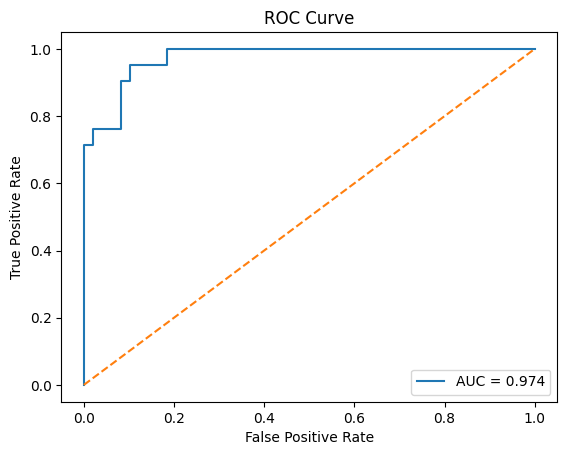

In [31]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(
    y_train_model,
    y_prob_train
)

# Plot ROC curve
plt.plot(
    fpr,
    tpr,
    label=f"AUC = {auc_score:.3f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

Step 17 — Gini Coefficient

In [32]:
# Calculate Gini
gini_score = (2 * auc_score) - 1

print("Gini Coefficient:", round(gini_score, 4))
print("Gini (%):", round(gini_score * 100, 2), "%")

Gini Coefficient: 0.9475
Gini (%): 94.75 %


Step 18 — KS Statistic

In [33]:
# Create KS data
ks_data = pd.DataFrame({
    "Actual": y_train_model,
    "PD": y_prob_train
})

# Sort by predicted PD
ks_data = ks_data.sort_values(
    "PD",
    ascending=False
).reset_index(drop=True)

# Calculate cumulative distributions
ks_data["Cumulative_Default"] = (
    ks_data["Actual"].cumsum() /
    ks_data["Actual"].sum()
)

ks_data["Cumulative_Non_Default"] = (
    (1 - ks_data["Actual"]).cumsum() /
    (1 - ks_data["Actual"]).sum()
)

# Calculate KS
ks_data["KS"] = (
    ks_data["Cumulative_Default"] -
    ks_data["Cumulative_Non_Default"]
).abs()

# Maximum KS
ks_statistic = ks_data["KS"].max()

print("KS Statistic:", round(ks_statistic, 4))
print("KS (%):", round(ks_statistic * 100, 2), "%")

KS Statistic: 0.8503
KS (%): 85.03 %


In [34]:
# Find maximum KS row
max_ks_row = ks_data.loc[
    ks_data["KS"].idxmax()
]

print("\nMaximum KS Point:")
print(max_ks_row)


Maximum KS Point:
Actual                    1.000000
PD                        0.346669
Cumulative_Default        0.952381
Cumulative_Non_Default    0.102041
KS                        0.850340
Name: 24, dtype: float64


Step 19 — Confusion Matrix & Classification Metrics

In [35]:
from sklearn.metrics import confusion_matrix

# Set classification cutoff
cutoff = 0.50

# Convert PD to class
y_pred_train = (
    y_prob_train >= cutoff
).astype(int)

# Create confusion matrix
cm = confusion_matrix(
    y_train_model,
    y_pred_train
)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[46  3]
 [ 5 16]]


In [36]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Calculate metrics
accuracy = accuracy_score(
    y_train_model,
    y_pred_train
)

precision = precision_score(
    y_train_model,
    y_pred_train,
    zero_division=0
)

recall = recall_score(
    y_train_model,
    y_pred_train,
    zero_division=0
)

f1 = f1_score(
    y_train_model,
    y_pred_train,
    zero_division=0
)

# Display metrics
print("Accuracy:", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall:", round(recall, 4))
print("F1 Score:", round(f1, 4))

Accuracy: 0.8857
Precision: 0.8421
Recall: 0.7619
F1 Score: 0.8


In [37]:
# Create classification summary
classification_metrics = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],
    "Value": [
        accuracy,
        precision,
        recall,
        f1
    ]
})

print(
    classification_metrics.round(4)
)

      Metric   Value
0   Accuracy  0.8857
1  Precision  0.8421
2     Recall  0.7619
3   F1 Score  0.8000


Step 20 — Probability Calibration

In [38]:
# Create calibration dataset
calibration_data = pd.DataFrame({
    "Actual_Default": y_train_model,
    "Predicted_PD": y_prob_train
})

# Create PD bands
calibration_data["PD_Band"] = pd.qcut(
    calibration_data["Predicted_PD"],
    q=10,
    duplicates="drop"
)

# Calculate calibration statistics
calibration_table = (
    calibration_data
    .groupby("PD_Band", observed=False)
    .agg(
        Customers=("Actual_Default", "count"),
        Average_PD=("Predicted_PD", "mean"),
        Actual_Default_Rate=("Actual_Default", "mean")
    )
    .reset_index()
)

# Convert rates to percentages
calibration_table["Average_PD"] *= 100
calibration_table["Actual_Default_Rate"] *= 100

print("Calibration Table:")
print(
    calibration_table.round(2)
)

Calibration Table:
             PD_Band  Customers  Average_PD  Actual_Default_Rate
0  (0.00265, 0.0227]          7        1.11                 0.00
1   (0.0227, 0.0428]          7        3.11                 0.00
2    (0.0428, 0.062]          7        5.18                 0.00
3    (0.062, 0.0849]          7        7.37                 0.00
4    (0.0849, 0.123]          7        9.93                 0.00
5     (0.123, 0.221]          7       16.49                14.29
6     (0.221, 0.402]          7       31.15                42.86
7     (0.402, 0.669]          7       55.07                42.86
8     (0.669, 0.901]          7       78.75               100.00
9     (0.901, 0.953]          7       91.83               100.00


In [39]:
# Calculate calibration difference
calibration_table["Calibration_Difference"] = (
    calibration_table["Average_PD"] -
    calibration_table["Actual_Default_Rate"]
)

print("Calibration Results:")
print(
    calibration_table[
        [
            "PD_Band",
            "Average_PD",
            "Actual_Default_Rate",
            "Calibration_Difference"
        ]
    ].round(2)
)

Calibration Results:
             PD_Band  Average_PD  Actual_Default_Rate  Calibration_Difference
0  (0.00265, 0.0227]        1.11                 0.00                    1.11
1   (0.0227, 0.0428]        3.11                 0.00                    3.11
2    (0.0428, 0.062]        5.18                 0.00                    5.18
3    (0.062, 0.0849]        7.37                 0.00                    7.37
4    (0.0849, 0.123]        9.93                 0.00                    9.93
5     (0.123, 0.221]       16.49                14.29                    2.21
6     (0.221, 0.402]       31.15                42.86                  -11.70
7     (0.402, 0.669]       55.07                42.86                   12.22
8     (0.669, 0.901]       78.75               100.00                  -21.25
9     (0.901, 0.953]       91.83               100.00                   -8.17


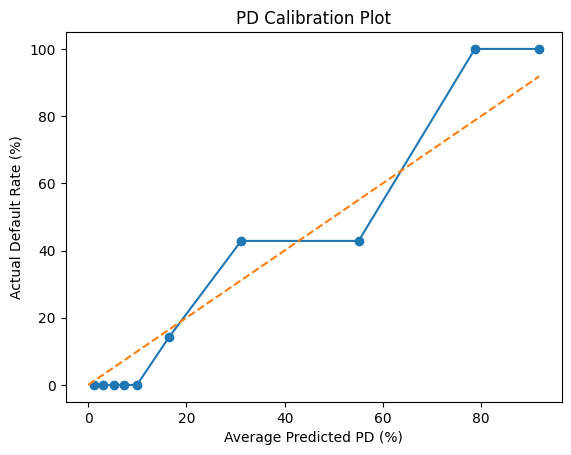

In [40]:
import matplotlib.pyplot as plt

# Plot predicted vs actual PD
plt.plot(
    calibration_table["Average_PD"],
    calibration_table["Actual_Default_Rate"],
    marker="o"
)

# Add perfect calibration line
max_pd = calibration_table["Average_PD"].max()

plt.plot(
    [0, max_pd],
    [0, max_pd],
    linestyle="--"
)

plt.xlabel("Average Predicted PD (%)")
plt.ylabel("Actual Default Rate (%)")
plt.title("PD Calibration Plot")
plt.show()

Step 21 — Score Distribution

In [41]:
# Score summary
score_summary = score_train["Score"].describe()

print("Score Summary:")
print(
    score_summary.round(2)
)

Score Summary:
count     70.00
mean     528.25
std       62.22
min      400.16
25%      478.63
50%      544.00
75%      570.34
max      648.97
Name: Score, dtype: float64


Step 21 — Score Distribution

In [42]:
# Score summary
score_summary = score_train["Score"].describe()

print("Score Summary:")
print(
    score_summary.round(2)
)

Score Summary:
count     70.00
mean     528.25
std       62.22
min      400.16
25%      478.63
50%      544.00
75%      570.34
max      648.97
Name: Score, dtype: float64


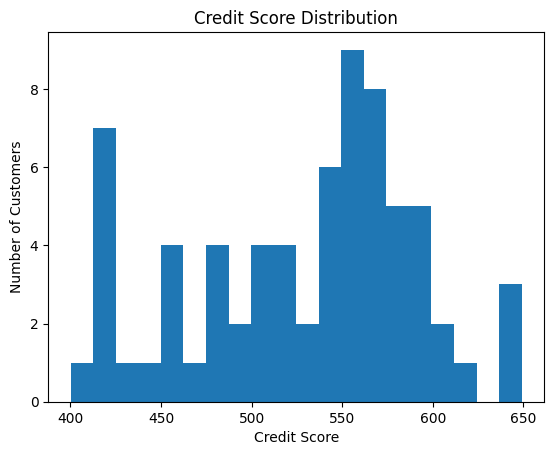

In [43]:
import matplotlib.pyplot as plt

# Plot score distribution
plt.hist(
    score_train["Score"],
    bins=20
)

plt.xlabel("Credit Score")
plt.ylabel("Number of Customers")
plt.title("Credit Score Distribution")
plt.show()

In [44]:
# Check score and PD relationship
score_pd_check = score_train[
    ["Score", "PD"]
].sort_values(
    "Score",
    ascending=False
)

print("Highest Score Customers:")
print(
    score_pd_check.head(10).round(4)
)

print("\nLowest Score Customers:")
print(
    score_pd_check.tail(10).round(4)
)

Highest Score Customers:
       Score      PD
1   648.9694  0.0037
49  643.6407  0.0044
69  637.7991  0.0054
67  622.8063  0.0090
24  607.6428  0.0151
42  602.6902  0.0179
98  596.4790  0.0221
22  595.6584  0.0227
90  590.8770  0.0267
4   590.7041  0.0269

Lowest Score Customers:
       Score      PD
57  440.6077  0.8337
23  437.1929  0.8495
80  423.4415  0.9009
34  422.0139  0.9052
6   420.9203  0.9084
66  420.6993  0.9090
43  418.9899  0.9138
85  418.4940  0.9152
0   415.3757  0.9232
52  400.1566  0.9532


Step 22 — Bad Rate by Score Band

In [45]:
# Create score data
score_data = score_train.copy()

score_data["Actual_Default"] = y_train_model.values

# Sort by score
score_data = score_data.sort_values(
    "Score",
    ascending=False
).reset_index(drop=True)

# Create 10 score bands
score_data["Score_Band"] = pd.qcut(
    score_data.index,
    q=10,
    labels=False
) + 1

print(score_data.head())

         PD       Score  Actual_Default  Score_Band
0  0.003651  648.969408               0           1
1  0.004388  643.640697               0           1
2  0.005367  637.799136               0           1
3  0.008992  622.806277               0           1
4  0.015114  607.642815               0           1


In [46]:
# Calculate bad rate by score band
bad_rate_table = (
    score_data
    .groupby("Score_Band")
    .agg(
        Customers=("Actual_Default", "count"),
        Average_Score=("Score", "mean"),
        Average_PD=("PD", "mean"),
        Bad_Rate=("Actual_Default", "mean")
    )
    .reset_index()
)

# Convert rates to percentages
bad_rate_table["Average_PD"] *= 100
bad_rate_table["Bad_Rate"] *= 100

print("Bad Rate by Score Band:")
print(
    bad_rate_table.round(2)
)

Bad Rate by Score Band:
   Score_Band  Customers  Average_Score  Average_PD  Bad_Rate
0           1          7         622.86        1.11      0.00
1           2          7         586.92        3.11      0.00
2           3          7         571.18        5.18      0.00
3           4          7         560.30        7.37      0.00
4           5          7         550.86        9.93      0.00
5           6          7         534.45       16.49     14.29
6           7          7         510.53       31.15     42.86
7           8          7         481.13       55.07     42.86
8           9          7         447.65       78.75    100.00
9          10          7         416.66       91.83    100.00


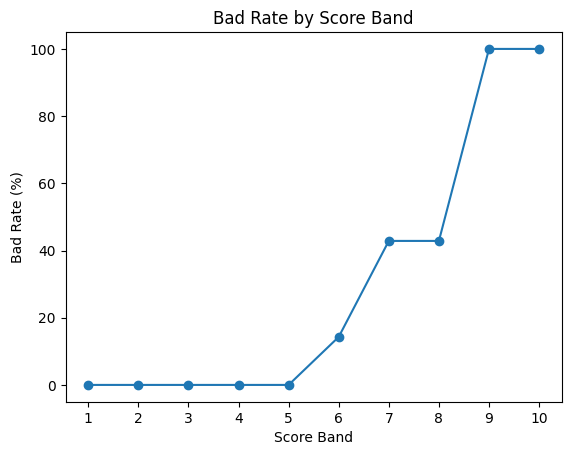

In [47]:
import matplotlib.pyplot as plt

# Plot bad rate
plt.plot(
    bad_rate_table["Score_Band"],
    bad_rate_table["Bad_Rate"],
    marker="o"
)

plt.xlabel("Score Band")
plt.ylabel("Bad Rate (%)")
plt.title("Bad Rate by Score Band")
plt.xticks(
    bad_rate_table["Score_Band"]
)
plt.show()

Step 23 — Decile Analysis

In [48]:
# Create decile data
decile_data = pd.DataFrame({
    "PD": train_pd,
    "Score": score_train["Score"].values,
    "Actual_Default": y_train_model.values
})

# Sort by highest PD
decile_data = decile_data.sort_values(
    "PD",
    ascending=False
).reset_index(drop=True)

# Create 10 deciles
decile_data["Decile"] = pd.qcut(
    decile_data.index,
    q=10,
    labels=False
) + 1

print(decile_data.head())

         PD       Score  Actual_Default  Decile
0  0.953204  400.156568               1       1
1  0.923195  415.375663               1       1
2  0.915173  418.494012               1       1
3  0.913829  418.989886               1       1
4  0.909048  420.699322               1       1


In [49]:
# Calculate decile statistics
decile_table = (
    decile_data
    .groupby("Decile")
    .agg(
        Customers=("Actual_Default", "count"),
        Average_PD=("PD", "mean"),
        Average_Score=("Score", "mean"),
        Actual_Bad_Rate=("Actual_Default", "mean"),
        Defaults=("Actual_Default", "sum")
    )
    .reset_index()
)

# Calculate cumulative defaults
decile_table["Cumulative_Defaults"] = (
    decile_table["Defaults"].cumsum()
)

# Calculate cumulative default capture
total_defaults = decile_table["Defaults"].sum()

decile_table["Cumulative_Default_Capture"] = (
    decile_table["Cumulative_Defaults"] /
    total_defaults
)

# Convert rates to percentages
decile_table["Average_PD"] *= 100
decile_table["Actual_Bad_Rate"] *= 100
decile_table["Cumulative_Default_Capture"] *= 100

print("Decile Analysis:")
print(
    decile_table.round(2)
)

Decile Analysis:
   Decile  Customers  Average_PD  Average_Score  Actual_Bad_Rate  Defaults  \
0       1          7       91.83         416.66           100.00         7   
1       2          7       78.75         447.65           100.00         7   
2       3          7       55.07         481.13            42.86         3   
3       4          7       31.15         510.53            42.86         3   
4       5          7       16.49         534.45            14.29         1   
5       6          7        9.93         550.86             0.00         0   
6       7          7        7.37         560.30             0.00         0   
7       8          7        5.18         571.18             0.00         0   
8       9          7        3.11         586.92             0.00         0   
9      10          7        1.11         622.86             0.00         0   

   Cumulative_Defaults  Cumulative_Default_Capture  
0                    7                       33.33  
1                 

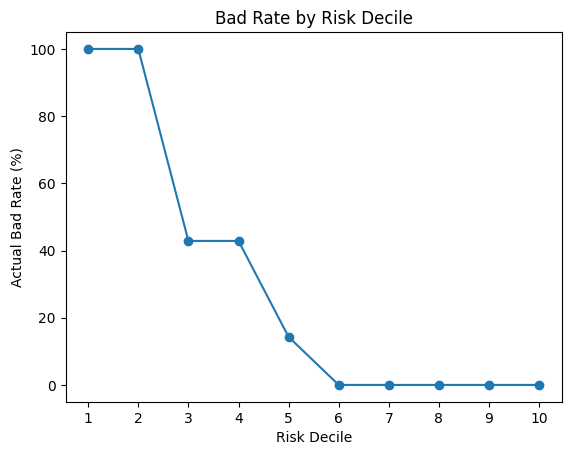

In [50]:
# Plot bad rate by decile
plt.plot(
    decile_table["Decile"],
    decile_table["Actual_Bad_Rate"],
    marker="o"
)

plt.xlabel("Risk Decile")
plt.ylabel("Actual Bad Rate (%)")
plt.title("Bad Rate by Risk Decile")
plt.xticks(
    decile_table["Decile"]
)
plt.show()

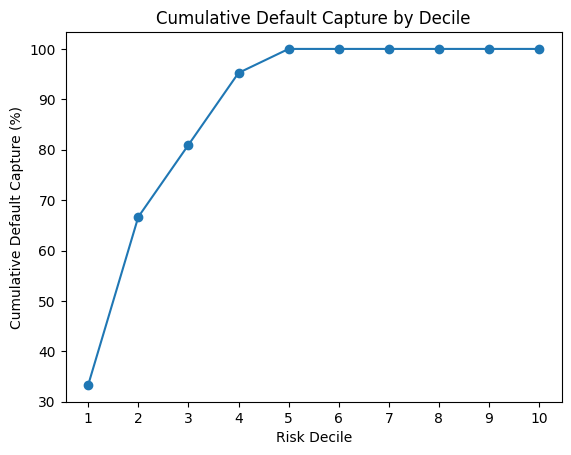

In [51]:
# Plot cumulative default capture
plt.plot(
    decile_table["Decile"],
    decile_table["Cumulative_Default_Capture"],
    marker="o"
)

plt.xlabel("Risk Decile")
plt.ylabel("Cumulative Default Capture (%)")
plt.title("Cumulative Default Capture by Decile")
plt.xticks(
    decile_table["Decile"]
)
plt.show()

Step 24 — Train vs Test Performance

In [52]:
# Create test dataset
test_data = X_test.copy()

# Add target
test_data[target] = y_test

print("Test Data Shape:", test_data.shape)
print(test_data.head())

Test Data Shape: (30, 32)
    Age  Income_INR  Employment_Years Marital_Status Education_Level  \
48   40      275766                11       Divorced        Graduate   
86   21     1037291                21         Single        Graduate   
33   35     2221900                 9         Single    Postgraduate   
26   42      969598                10       Divorced        Graduate   
29   47     1659933                24         Single             PhD   

    Credit_History_Length  Outstanding_Loans  Loan_Amount  Loan_Tenure_Months  \
48                      2                  2       250244                  60   
86                      9                  7       748168                  12   
33                      1                  2      1204146                  60   
26                      1                  3       319114                  48   
29                      5                  8      1931548                  24   

    Savings_Account_Balance  ...  No_of_Inquiries_12M 

In [53]:
# Create training data
train_data = X_train.copy()
train_data[target] = y_train

# Store training bin edges
bin_edges = {}

# Recreate training bins
binned_train = train_data.copy()

for col in numeric_cols:
    try:
        binned_train[col], edges = pd.qcut(
            train_data[col],
            q=5,
            retbins=True,
            duplicates="drop"
        )

        bin_edges[col] = edges

    except:
        pass

# Keep categorical variables
for col in categorical_cols:
    binned_train[col] = train_data[col].astype(str)

print("Training bin edges recreated.")
print("Number of numeric variables:", len(bin_edges))

Training bin edges recreated.
Number of numeric variables: 28


In [54]:
# Recalculate training WoE
woe_results = {}

for col in final_variables:
    woe_results[col] = calculate_woe(
        binned_train,
        col,
        target
    )

print("Training WoE mappings recreated.")

Training WoE mappings recreated.


In [55]:
# Recreate test bins
binned_test = test_data.copy()

for col in numeric_cols:
    if col in bin_edges:

        test_bins = pd.cut(
            test_data[col],
            bins=bin_edges[col],
            include_lowest=True
        )

        # Get training bin categories
        categories = binned_train[col].cat.categories

        # Convert for reassignment
        test_bins = test_bins.astype(object)

        # Assign below-range values to first bin
        test_bins.loc[
            test_data[col] < bin_edges[col][0]
        ] = categories[0]

        # Assign above-range values to last bin
        test_bins.loc[
            test_data[col] > bin_edges[col][-1]
        ] = categories[-1]

        binned_test[col] = test_bins

# Keep categorical variables
for col in categorical_cols:
    binned_test[col] = test_data[col].astype(str)

In [56]:
# Create test WoE dataset
woe_test = pd.DataFrame(
    index=test_data.index
)

# Apply training WoE mappings
for col in final_variables:
    woe_test[col] = binned_test[col].map(
        woe_results[col]["WoE"]
    )

# Add target
woe_test[target] = test_data[target]

# Check missing WoE
missing_woe = (
    woe_test[final_variables]
    .isnull()
    .sum()
)

print("Missing WoE Values:")
print(
    missing_woe[missing_woe > 0]
)

print(
    "\nTotal Missing WoE Values:",
    missing_woe.sum()
)

Missing WoE Values:
Series([], dtype: int64)

Total Missing WoE Values: 0


In [57]:
# Prepare test features
X_test_woe = woe_test[final_variables]
y_test_model = woe_test[target]

# Predict test PD
test_pd = logit_model.predict_proba(
    X_test_woe
)[:, 1]

print("Test PD Summary:")
print(
    pd.Series(test_pd).describe().round(4)
)

Test PD Summary:
count    30.0000
mean      0.3320
std       0.2723
min       0.0172
25%       0.0490
50%       0.3746
75%       0.5308
max       0.9713
dtype: float64


In [58]:
from sklearn.metrics import roc_auc_score

# Calculate test AUC
test_auc = roc_auc_score(
    y_test_model,
    test_pd
)

print("Test ROC-AUC:", round(test_auc, 4))

Test ROC-AUC: 0.5503


In [59]:
# Calculate test Gini
test_gini = (
    2 * test_auc
) - 1

print("Test Gini:", round(test_gini, 4))
print("Test Gini (%):", round(test_gini * 100, 2), "%")

Test Gini: 0.1005
Test Gini (%): 10.05 %


In [60]:
# Create test KS data
test_ks_data = pd.DataFrame({
    "Actual": y_test_model,
    "PD": test_pd
})

# Sort by predicted PD
test_ks_data = test_ks_data.sort_values(
    "PD",
    ascending=False
).reset_index(drop=True)

# Calculate cumulative distributions
test_ks_data["Cumulative_Default"] = (
    test_ks_data["Actual"].cumsum() /
    test_ks_data["Actual"].sum()
)

test_ks_data["Cumulative_Non_Default"] = (
    (1 - test_ks_data["Actual"]).cumsum() /
    (1 - test_ks_data["Actual"]).sum()
)

# Calculate KS
test_ks_data["KS"] = (
    test_ks_data["Cumulative_Default"] -
    test_ks_data["Cumulative_Non_Default"]
).abs()

# Maximum KS
test_ks = test_ks_data["KS"].max()

print("Test KS:", round(test_ks, 4))
print("Test KS (%):", round(test_ks * 100, 2), "%")

Test KS: 0.1746
Test KS (%): 17.46 %


In [61]:
# Compare train and test performance
performance_comparison = pd.DataFrame({
    "Metric": [
        "AUC",
        "Gini",
        "KS"
    ],
    "Train": [
        auc_score,
        gini_score,
        ks_statistic
    ],
    "Test": [
        test_auc,
        test_gini,
        test_ks
    ]
})

# Calculate train-test difference
performance_comparison["Difference"] = (
    performance_comparison["Train"] -
    performance_comparison["Test"]
)

print("Train vs Test Performance:")
print(
    performance_comparison.round(4)
)

Train vs Test Performance:
  Metric   Train    Test  Difference
0    AUC  0.9738  0.5503      0.4235
1   Gini  0.9475  0.1005      0.8470
2     KS  0.8503  0.1746      0.6757


Step 25 — Population Stability Index (PSI)

In [62]:
# Calculate test score
test_non_default_odds = (
    (1 - test_pd) / test_pd
)

test_score = (
    offset +
    factor * np.log(test_non_default_odds)
)

# Create score datasets
train_scores = pd.Series(
    train_score,
    name="Score"
)

test_scores = pd.Series(
    test_score,
    name="Score"
)

print("Train Score Summary:")
print(train_scores.describe().round(2))

print("\nTest Score Summary:")
print(test_scores.describe().round(2))

Train Score Summary:
count     70.00
mean     528.25
std       62.22
min      400.16
25%      478.63
50%      544.00
75%      570.34
max      648.97
Name: Score, dtype: float64

Test Score Summary:
count     30.00
mean     520.10
std       53.77
min      385.52
25%      483.56
50%      501.94
75%      572.74
max      603.85
Name: Score, dtype: float64


In [63]:
# Create score band boundaries from training data
score_bins = np.quantile(
    train_scores,
    np.linspace(0, 1, 11)
)

# Remove duplicate boundaries
score_bins = np.unique(score_bins)

print("Score Bin Boundaries:")
print(score_bins)

Score Bin Boundaries:
[400.15656829 423.29874731 466.7834865  498.59395154 523.50902519
 544.00339457 555.7333368  565.50837832 576.81428815 595.74047876
 648.96940842]


In [64]:
# Assign score bands
train_score_bands = pd.cut(
    train_scores,
    bins=score_bins,
    include_lowest=True
)

test_score_bands = pd.cut(
    test_scores,
    bins=score_bins,
    include_lowest=True
)

# Calculate distributions
train_dist = (
    train_score_bands
    .value_counts(normalize=True)
    .sort_index()
)

test_dist = (
    test_score_bands
    .value_counts(normalize=True)
    .sort_index()
)

print("Train Distribution:")
print(train_dist.round(4))

print("\nTest Distribution:")
print(test_dist.round(4))

Train Distribution:
Score
(400.156, 423.299]    0.1
(423.299, 466.783]    0.1
(466.783, 498.594]    0.1
(498.594, 523.509]    0.1
(523.509, 544.003]    0.1
(544.003, 555.733]    0.1
(555.733, 565.508]    0.1
(565.508, 576.814]    0.1
(576.814, 595.74]     0.1
(595.74, 648.969]     0.1
Name: proportion, dtype: float64

Test Distribution:
Score
(400.156, 423.299]    0.0000
(423.299, 466.783]    0.0690
(466.783, 498.594]    0.3448
(498.594, 523.509]    0.1724
(523.509, 544.003]    0.0000
(544.003, 555.733]    0.0345
(555.733, 565.508]    0.0690
(565.508, 576.814]    0.1034
(576.814, 595.74]     0.1379
(595.74, 648.969]     0.0690
Name: proportion, dtype: float64


In [65]:
# Avoid zero proportions
epsilon = 0.0001

train_dist_adj = train_dist.clip(lower=epsilon)
test_dist_adj = test_dist.clip(lower=epsilon)

# Calculate PSI contribution
psi_contribution = (
    (test_dist_adj - train_dist_adj)
    * np.log(
        test_dist_adj / train_dist_adj
    )
)

# Create PSI table
psi_table = pd.DataFrame({
    "Train_%": train_dist * 100,
    "Test_%": test_dist * 100,
    "PSI_Contribution": psi_contribution
})

print("PSI Table:")
print(psi_table.round(4))

PSI Table:
                    Train_%   Test_%  PSI_Contribution
Score                                                 
(400.156, 423.299]     10.0   0.0000            0.6901
(423.299, 466.783]     10.0   6.8966            0.0115
(466.783, 498.594]     10.0  34.4828            0.3031
(498.594, 523.509]     10.0  17.2414            0.0394
(523.509, 544.003]     10.0   0.0000            0.6901
(544.003, 555.733]     10.0   3.4483            0.0698
(555.733, 565.508]     10.0   6.8966            0.0115
(565.508, 576.814]     10.0  10.3448            0.0001
(576.814, 595.74]      10.0  13.7931            0.0122
(595.74, 648.969]      10.0   6.8966            0.0115


In [66]:
# Calculate overall PSI
psi_score = psi_contribution.sum()

print("Overall PSI:", round(psi_score, 4))

Overall PSI: 1.8393


In [67]:
print("Train Score Range:")
print(train_scores.min(), train_scores.max())

print("\nTest Score Range:")
print(test_scores.min(), test_scores.max())

print("\nPSI Table:")
print(psi_table.round(4))

Train Score Range:
400.156568293073 648.9694084229075

Test Score Range:
385.51929944499057 603.8450176281917

PSI Table:
                    Train_%   Test_%  PSI_Contribution
Score                                                 
(400.156, 423.299]     10.0   0.0000            0.6901
(423.299, 466.783]     10.0   6.8966            0.0115
(466.783, 498.594]     10.0  34.4828            0.3031
(498.594, 523.509]     10.0  17.2414            0.0394
(523.509, 544.003]     10.0   0.0000            0.6901
(544.003, 555.733]     10.0   3.4483            0.0698
(555.733, 565.508]     10.0   6.8966            0.0115
(565.508, 576.814]     10.0  10.3448            0.0001
(576.814, 595.74]      10.0  13.7931            0.0122
(595.74, 648.969]      10.0   6.8966            0.0115


In [68]:
print("Train Score Quantiles:")
print(
    train_scores.quantile(
        [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1]
    ).round(2)
)

print("\nTest Score Quantiles:")
print(
    test_scores.quantile(
        [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1]
    ).round(2)
)

Train Score Quantiles:
0.0    400.16
0.1    423.30
0.2    466.78
0.3    498.59
0.4    523.51
0.5    544.00
0.6    555.73
0.7    565.51
0.8    576.81
0.9    595.74
1.0    648.97
Name: Score, dtype: float64

Test Score Quantiles:
0.0    385.52
0.1    473.40
0.2    479.28
0.3    488.78
0.4    495.78
0.5    501.94
0.6    527.61
0.7    563.78
0.8    577.16
0.9    589.10
1.0    603.85
Name: Score, dtype: float64


Step 26 — Variable-Level Stability

In [69]:
# Calculate PSI for one variable
def calculate_psi(train_data, test_data, variable, bins):

    # Create train and test bins
    train_bins = pd.cut(
        train_data[variable],
        bins=bins,
        include_lowest=True
    )

    test_bins = pd.cut(
        test_data[variable],
        bins=bins,
        include_lowest=True
    )

    # Calculate distributions
    train_dist = (
        train_bins
        .value_counts(normalize=True)
        .sort_index()
    )

    test_dist = (
        test_bins
        .value_counts(normalize=True)
        .sort_index()
    )

    # Align distributions
    distribution = pd.DataFrame({
        "Train": train_dist,
        "Test": test_dist
    }).fillna(0)

    # Avoid zero values
    epsilon = 0.0001

    train_adj = distribution["Train"].clip(
        lower=epsilon
    )

    test_adj = distribution["Test"].clip(
        lower=epsilon
    )

    # Calculate PSI
    psi = (
        (test_adj - train_adj)
        * np.log(test_adj / train_adj)
    ).sum()

    return psi

In [70]:
# Calculate PSI for numerical variables
variable_psi_results = []

for col in final_variables:

    if col in bin_edges:

        psi = calculate_psi(
            train_data,
            test_data,
            col,
            bin_edges[col]
        )

        variable_psi_results.append({
            "Variable": col,
            "PSI": psi
        })

# Create PSI table
variable_psi_table = pd.DataFrame(
    variable_psi_results
)

# Sort by PSI
variable_psi_table = (
    variable_psi_table
    .sort_values(
        "PSI",
        ascending=False
    )
    .reset_index(drop=True)
)

print("Variable-Level PSI:")
print(
    variable_psi_table.round(4)
)

Variable-Level PSI:
                                Variable     PSI
0                                    Age  0.5381
1                  Total_Current_Balance  0.4682
2               Newest_Trade_Open_Months  0.3975
3                     Total_Credit_Limit  0.3941
4                             Income_INR  0.3421
5                       Employment_Years  0.3274
6                      Outstanding_Loans  0.3274
7               Behavior_Repayment_Score  0.2982
8                     Loan_Tenure_Months  0.2742
9               Oldest_Trade_Open_Months  0.2654
10                 No_of_Closed_Accounts  0.2420
11                 Credit_History_Length  0.2282
12              Credit_Utilization_Ratio  0.2179
13                   No_of_Inquiries_12M  0.1842
14               Credit_Card_Utilization  0.1834
15              Checking_Account_Balance  0.1510
16               Behavior_Spending_Score  0.1414
17  Months_Since_Most_Recent_Delinquency  0.1374
18                           Loan_Amount  0.1293


In [71]:
# Classify PSI
def psi_status(psi):

    if psi < 0.10:
        return "Stable"

    elif psi < 0.25:
        return "Moderate Shift"

    else:
        return "Significant Shift"


variable_psi_table["Status"] = (
    variable_psi_table["PSI"]
    .apply(psi_status)
)

print("Variable Stability:")
print(variable_psi_table)

Variable Stability:
                                Variable       PSI             Status
0                                    Age  0.538062  Significant Shift
1                  Total_Current_Balance  0.468213  Significant Shift
2               Newest_Trade_Open_Months  0.397492  Significant Shift
3                     Total_Credit_Limit  0.394121  Significant Shift
4                             Income_INR  0.342123  Significant Shift
5                       Employment_Years  0.327449  Significant Shift
6                      Outstanding_Loans  0.327411  Significant Shift
7               Behavior_Repayment_Score  0.298226  Significant Shift
8                     Loan_Tenure_Months  0.274218  Significant Shift
9               Oldest_Trade_Open_Months  0.265448  Significant Shift
10                 No_of_Closed_Accounts  0.242004     Moderate Shift
11                 Credit_History_Length  0.228167     Moderate Shift
12              Credit_Utilization_Ratio  0.217900     Moderate Shift


In [72]:
# Count stability categories
print(
    variable_psi_table["Status"]
    .value_counts()
)

Status
Significant Shift    10
Moderate Shift       10
Stable                7
Name: count, dtype: int64


In [73]:
print(
    variable_psi_table[
        ["Variable", "PSI", "Status"]
    ].round(4)
)

                                Variable     PSI             Status
0                                    Age  0.5381  Significant Shift
1                  Total_Current_Balance  0.4682  Significant Shift
2               Newest_Trade_Open_Months  0.3975  Significant Shift
3                     Total_Credit_Limit  0.3941  Significant Shift
4                             Income_INR  0.3421  Significant Shift
5                       Employment_Years  0.3274  Significant Shift
6                      Outstanding_Loans  0.3274  Significant Shift
7               Behavior_Repayment_Score  0.2982  Significant Shift
8                     Loan_Tenure_Months  0.2742  Significant Shift
9               Oldest_Trade_Open_Months  0.2654  Significant Shift
10                 No_of_Closed_Accounts  0.2420     Moderate Shift
11                 Credit_History_Length  0.2282     Moderate Shift
12              Credit_Utilization_Ratio  0.2179     Moderate Shift
13                   No_of_Inquiries_12M  0.1842

Step 27 — EAD (Exposure at Default)

In [74]:
# Review exposure variables
ead_variables = [
    "Outstanding_Loans",
    "Loan_Amount",
    "Total_Current_Balance",
    "Max_Credit_Exposure"
]

print("EAD Variables:")
print(
    df[ead_variables].describe().T.round(2)
)

EAD Variables:
                       count        mean        std      min        25%  \
Outstanding_Loans      100.0        4.80       2.92      0.0       2.00   
Loan_Amount            100.0   978307.32  528227.90  50404.0  585982.25   
Total_Current_Balance  100.0  1246230.05  714233.71  13115.0  661175.00   
Max_Credit_Exposure    100.0  1091680.29  553493.56  51852.0  551650.25   

                             50%         75%        max  
Outstanding_Loans            5.0        7.25        9.0  
Loan_Amount             924357.5  1398375.50  1993327.0  
Total_Current_Balance  1261513.5  1852193.75  2495838.0  
Max_Credit_Exposure    1144649.0  1555581.00  1980584.0  


In [75]:
# Create EAD proxy
df["EAD"] = df["Outstanding_Loans"]

print("EAD Summary:")
print(
    df["EAD"].describe().round(2)
)

EAD Summary:
count    100.00
mean       4.80
std        2.92
min        0.00
25%        2.00
50%        5.00
75%        7.25
max        9.00
Name: EAD, dtype: float64


In [76]:
# Check EAD values
print(
    df[
        [
            "Customer_ID",
            "Outstanding_Loans",
            "EAD"
        ]
    ].head(10)
)

   Customer_ID  Outstanding_Loans  EAD
0            1                  9    9
1            2                  6    6
2            3                  9    9
3            4                  4    4
4            5                  2    2
5            6                  6    6
6            7                  1    1
7            8                  8    8
8            9                  9    9
9           10                  9    9


In [77]:
# Compare EAD by default status
ead_by_default = (
    df.groupby("Default_y")["EAD"]
    .agg(
        Customers="count",
        Average_EAD="mean",
        Median_EAD="median",
        Total_EAD="sum"
    )
    .reset_index()
)

print("EAD by Default Status:")
print(
    ead_by_default.round(2)
)

EAD by Default Status:
   Default_y  Customers  Average_EAD  Median_EAD  Total_EAD
0          0         70         4.67         4.5        327
1          1         30         5.10         6.0        153


In [78]:
# Calculate portfolio EAD
total_ead = df["EAD"].sum()

default_ead = df.loc[
    df["Default_y"] == 1,
    "EAD"
].sum()

non_default_ead = df.loc[
    df["Default_y"] == 0,
    "EAD"
].sum()

print("Total Portfolio EAD:", round(total_ead, 2))
print("Defaulted Customer EAD:", round(default_ead, 2))
print("Non-Defaulted Customer EAD:", round(non_default_ead, 2))

Total Portfolio EAD: 480
Defaulted Customer EAD: 153
Non-Defaulted Customer EAD: 327


Step 28 — LGD (Loss Given Default)

In [79]:
# Set LGD assumption
lgd = 0.60

print("LGD:", lgd)
print("LGD (%):", lgd * 100, "%")

LGD: 0.6
LGD (%): 60.0 %


In [80]:
# Create training EAD
train_ead = df.loc[
    y_train_model.index,
    "EAD"
].values

# Calculate expected loss
train_expected_loss = (
    train_pd *
    lgd *
    train_ead
)

# Create expected loss table
expected_loss_train = pd.DataFrame({
    "Customer_ID": df.loc[
        y_train_model.index,
        "Customer_ID"
    ].values,
    "PD": train_pd,
    "LGD": lgd,
    "EAD": train_ead,
    "Expected_Loss": train_expected_loss
})

print("Expected Loss:")
print(
    expected_loss_train.head(10).round(2)
)

Expected Loss:
   Customer_ID    PD  LGD  EAD  Expected_Loss
0           68  0.01  0.6    1           0.01
1           21  0.09  0.6    4           0.22
2           47  0.60  0.6    6           2.15
3           83  0.10  0.6    7           0.43
4           94  0.21  0.6    0           0.00
5           85  0.07  0.6    3           0.12
6           99  0.02  0.6    2           0.03
7           52  0.08  0.6    8           0.36
8           24  0.85  0.6    7           3.57
9           22  0.11  0.6    5           0.34


In [81]:
# Calculate portfolio expected loss
total_expected_loss = (
    expected_loss_train["Expected_Loss"].sum()
)

print(
    "Total Expected Loss:",
    round(total_expected_loss, 2)
)

Total Expected Loss: 73.77


Step 29 — PD in the ECL Framework

In [82]:
# Create ECL PD dataset
ecl_data = expected_loss_train.copy()

# Use scorecard PD as 12-month PD proxy
ecl_data["PD_12M"] = ecl_data["PD"]

print("ECL PD Summary:")
print(
    ecl_data["PD_12M"].describe().round(4)
)

ECL PD Summary:
count    70.0000
mean      0.3000
std       0.3227
min       0.0037
25%       0.0529
50%       0.1226
75%       0.5730
max       0.9532
Name: PD_12M, dtype: float64


In [83]:
# Create risk categories
ecl_data["Risk_Category"] = pd.cut(
    ecl_data["PD_12M"],
    bins=[0, 0.05, 0.10, 0.20, 1],
    labels=[
        "Low Risk",
        "Moderate Risk",
        "High Risk",
        "Very High Risk"
    ],
    include_lowest=True
)

# Summarize PD by risk category
pd_risk_summary = (
    ecl_data
    .groupby("Risk_Category", observed=False)
    .agg(
        Customers=("PD_12M", "count"),
        Average_PD=("PD_12M", "mean"),
        Average_EAD=("EAD", "mean"),
        Total_EAD=("EAD", "sum")
    )
    .reset_index()
)

pd_risk_summary["Average_PD"] *= 100

print("PD by Risk Category:")
print(
    pd_risk_summary.round(2)
)

PD by Risk Category:
    Risk_Category  Customers  Average_PD  Average_EAD  Total_EAD
0        Low Risk         17        2.55         4.53         77
1   Moderate Risk         14        7.22         4.64         65
2       High Risk          9       12.73         3.56         32
3  Very High Risk         30       61.36         5.90        177


In [84]:
# Calculate expected loss
ecl_data["Expected_Loss"] = (
    ecl_data["PD_12M"]
    * ecl_data["LGD"]
    * ecl_data["EAD"]
)

# Summarize expected loss by risk category
ecl_risk_summary = (
    ecl_data
    .groupby("Risk_Category", observed=False)
    .agg(
        Customers=("PD_12M", "count"),
        Average_PD=("PD_12M", "mean"),
        Total_EAD=("EAD", "sum"),
        Expected_Loss=("Expected_Loss", "sum")
    )
    .reset_index()
)

ecl_risk_summary["Average_PD"] *= 100

print("Expected Loss by Risk Category:")
print(
    ecl_risk_summary.round(2)
)

Expected Loss by Risk Category:
    Risk_Category  Customers  Average_PD  Total_EAD  Expected_Loss
0        Low Risk         17        2.55         77           1.32
1   Moderate Risk         14        7.22         65           2.71
2       High Risk          9       12.73         32           2.50
3  Very High Risk         30       61.36        177          67.24


In [85]:
# Confirm total expected loss
total_ecl = ecl_data["Expected_Loss"].sum()

print(
    "Total Expected Loss:",
    round(total_ecl, 2)
)

Total Expected Loss: 73.77


Step 30 — ECL (Expected Credit Loss)

In [86]:
# Calculate customer-level ECL
ecl_data["ECL"] = (
    ecl_data["PD_12M"]
    * ecl_data["LGD"]
    * ecl_data["EAD"]
)

# Display ECL
print("Customer-Level ECL:")
print(
    ecl_data[
        [
            "Customer_ID",
            "PD_12M",
            "LGD",
            "EAD",
            "ECL"
        ]
    ].head(10).round(2)
)

Customer-Level ECL:
   Customer_ID  PD_12M  LGD  EAD   ECL
0           68    0.01  0.6    1  0.01
1           21    0.09  0.6    4  0.22
2           47    0.60  0.6    6  2.15
3           83    0.10  0.6    7  0.43
4           94    0.21  0.6    0  0.00
5           85    0.07  0.6    3  0.12
6           99    0.02  0.6    2  0.03
7           52    0.08  0.6    8  0.36
8           24    0.85  0.6    7  3.57
9           22    0.11  0.6    5  0.34


In [87]:
# Calculate portfolio totals
portfolio_ecl = pd.DataFrame({
    "Metric": [
        "Total EAD",
        "Average PD",
        "LGD",
        "Total ECL"
    ],
    "Value": [
        ecl_data["EAD"].sum(),
        ecl_data["PD_12M"].mean(),
        ecl_data["LGD"].mean(),
        ecl_data["ECL"].sum()
    ]
})

# Convert PD to percentage
portfolio_ecl.loc[
    portfolio_ecl["Metric"] == "Average PD",
    "Value"
] *= 100

# Display summary
print("Portfolio ECL Summary:")
print(
    portfolio_ecl.round(2)
)

Portfolio ECL Summary:
       Metric   Value
0   Total EAD  351.00
1  Average PD   30.00
2         LGD    0.60
3   Total ECL   73.77


In [88]:
# Calculate ECL by risk category
ecl_by_risk = (
    ecl_data
    .groupby("Risk_Category", observed=False)
    .agg(
        Customers=("Customer_ID", "count"),
        Average_PD=("PD_12M", "mean"),
        Total_EAD=("EAD", "sum"),
        Expected_Loss=("ECL", "sum")
    )
    .reset_index()
)

# Convert PD to percentage
ecl_by_risk["Average_PD"] *= 100

print("ECL by Risk Category:")
print(
    ecl_by_risk.round(2)
)

ECL by Risk Category:
    Risk_Category  Customers  Average_PD  Total_EAD  Expected_Loss
0        Low Risk         17        2.55         77           1.32
1   Moderate Risk         14        7.22         65           2.71
2       High Risk          9       12.73         32           2.50
3  Very High Risk         30       61.36        177          67.24


In [89]:
# Calculate ECL rate
total_ead = ecl_data["EAD"].sum()
total_ecl = ecl_data["ECL"].sum()

ecl_rate = (
    total_ecl / total_ead
)

print(
    "ECL as % of EAD:",
    round(ecl_rate * 100, 2),
    "%"
)

ECL as % of EAD: 21.02 %


Step 30 — Expected Credit Loss (ECL)

In [90]:
# Calculate customer-level ECL
ecl_data["ECL"] = (
    ecl_data["PD_12M"]
    * ecl_data["LGD"]
    * ecl_data["EAD"]
)

print("Customer-Level ECL:")
print(
    ecl_data[
        [
            "Customer_ID",
            "PD_12M",
            "LGD",
            "EAD",
            "ECL"
        ]
    ].head(10).round(2)
)

Customer-Level ECL:
   Customer_ID  PD_12M  LGD  EAD   ECL
0           68    0.01  0.6    1  0.01
1           21    0.09  0.6    4  0.22
2           47    0.60  0.6    6  2.15
3           83    0.10  0.6    7  0.43
4           94    0.21  0.6    0  0.00
5           85    0.07  0.6    3  0.12
6           99    0.02  0.6    2  0.03
7           52    0.08  0.6    8  0.36
8           24    0.85  0.6    7  3.57
9           22    0.11  0.6    5  0.34


In [91]:
# Calculate portfolio ECL
total_ead = ecl_data["EAD"].sum()
total_ecl = ecl_data["ECL"].sum()
average_pd = ecl_data["PD_12M"].mean()

print("Total EAD:", round(total_ead, 2))
print("Average PD:", round(average_pd * 100, 2), "%")
print("LGD:", round(lgd * 100, 2), "%")
print("Total ECL:", round(total_ecl, 2))

Total EAD: 351
Average PD: 30.0 %
LGD: 60.0 %
Total ECL: 73.77


In [92]:
# Calculate ECL as percentage of EAD
ecl_rate = total_ecl / total_ead

print(
    "ECL as % of EAD:",
    round(ecl_rate * 100, 2),
    "%"
)

ECL as % of EAD: 21.02 %


In [93]:
# Calculate ECL by risk category
ecl_by_risk = (
    ecl_data
    .groupby("Risk_Category", observed=False)
    .agg(
        Customers=("Customer_ID", "count"),
        Average_PD=("PD_12M", "mean"),
        Total_EAD=("EAD", "sum"),
        Total_ECL=("ECL", "sum")
    )
    .reset_index()
)

# Convert PD to percentage
ecl_by_risk["Average_PD"] *= 100

print("ECL by Risk Category:")
print(
    ecl_by_risk.round(2)
)

ECL by Risk Category:
    Risk_Category  Customers  Average_PD  Total_EAD  Total_ECL
0        Low Risk         17        2.55         77       1.32
1   Moderate Risk         14        7.22         65       2.71
2       High Risk          9       12.73         32       2.50
3  Very High Risk         30       61.36        177      67.24


Step 31 — Risk Tier / Portfolio Analysis

In [94]:
# Summarize portfolio by risk category
risk_tier_summary = (
    ecl_data
    .groupby("Risk_Category", observed=False)
    .agg(
        Customers=("Customer_ID", "count"),
        Average_PD=("PD_12M", "mean"),
        Total_EAD=("EAD", "sum"),
        Total_ECL=("ECL", "sum")
    )
    .reset_index()
)

# Calculate portfolio percentages
total_customers = risk_tier_summary["Customers"].sum()
total_ead = risk_tier_summary["Total_EAD"].sum()
total_ecl = risk_tier_summary["Total_ECL"].sum()

risk_tier_summary["Customer_%"] = (
    risk_tier_summary["Customers"] /
    total_customers * 100
)

risk_tier_summary["EAD_%"] = (
    risk_tier_summary["Total_EAD"] /
    total_ead * 100
)

risk_tier_summary["ECL_%"] = (
    risk_tier_summary["Total_ECL"] /
    total_ecl * 100
)

# Convert PD to percentage
risk_tier_summary["Average_PD"] *= 100

print("Risk Tier Portfolio Summary:")
print(
    risk_tier_summary.round(2)
)

Risk Tier Portfolio Summary:
    Risk_Category  Customers  Average_PD  Total_EAD  Total_ECL  Customer_%  \
0        Low Risk         17        2.55         77       1.32       24.29   
1   Moderate Risk         14        7.22         65       2.71       20.00   
2       High Risk          9       12.73         32       2.50       12.86   
3  Very High Risk         30       61.36        177      67.24       42.86   

   EAD_%  ECL_%  
0  21.94   1.79  
1  18.52   3.68  
2   9.12   3.39  
3  50.43  91.15  


In [95]:
# Sort by expected loss
ecl_contribution = risk_tier_summary[
    [
        "Risk_Category",
        "Customers",
        "Customer_%",
        "Average_PD",
        "Total_EAD",
        "EAD_%",
        "Total_ECL",
        "ECL_%"
    ]
].sort_values(
    "Total_ECL",
    ascending=False
)

print("ECL Contribution by Risk Tier:")
print(
    ecl_contribution.round(2)
)

ECL Contribution by Risk Tier:
    Risk_Category  Customers  Customer_%  Average_PD  Total_EAD  EAD_%  \
3  Very High Risk         30       42.86       61.36        177  50.43   
1   Moderate Risk         14       20.00        7.22         65  18.52   
2       High Risk          9       12.86       12.73         32   9.12   
0        Low Risk         17       24.29        2.55         77  21.94   

   Total_ECL  ECL_%  
3      67.24  91.15  
1       2.71   3.68  
2       2.50   3.39  
0       1.32   1.79  


In [96]:
# Identify highest ECL risk tier
highest_ecl_tier = risk_tier_summary.loc[
    risk_tier_summary["Total_ECL"].idxmax()
]

print("Highest ECL Risk Tier:")
print(highest_ecl_tier)

Highest ECL Risk Tier:
Risk_Category    Very High Risk
Customers                    30
Average_PD            61.364897
Total_EAD                   177
Total_ECL             67.241154
Customer_%            42.857143
EAD_%                  50.42735
ECL_%                 91.150893
Name: 3, dtype: object


In [97]:
# Identify highest ECL risk tier
highest_ecl_tier = risk_tier_summary.loc[
    risk_tier_summary["Total_ECL"].idxmax()
]

print("Highest ECL Risk Tier:")
print("Risk Category:", highest_ecl_tier["Risk_Category"])
print("Customers:", highest_ecl_tier["Customers"])
print("Average PD:", round(highest_ecl_tier["Average_PD"], 2), "%")
print("Total EAD:", round(highest_ecl_tier["Total_EAD"], 2))
print("Total ECL:", round(highest_ecl_tier["Total_ECL"], 2))

Highest ECL Risk Tier:
Risk Category: Very High Risk
Customers: 30
Average PD: 61.36 %
Total EAD: 177
Total ECL: 67.24


Step 32 — Basel Capital / Risk-Weighted Assets (RWA)

In [98]:
# Step 32.1 — Assign numeric risk weights

risk_weights = {
    "Low Risk": 0.20,
    "Moderate Risk": 0.50,
    "High Risk": 0.75,
    "Very High Risk": 1.00
}

ecl_data["Risk_Weight"] = (
    ecl_data["Risk_Category"]
    .astype(str)
    .map(risk_weights)
)

ecl_data[[
    "Customer_ID",
    "Risk_Category",
    "EAD",
    "Risk_Weight"
]].head()

,Customer_ID,Risk_Category,EAD,Risk_Weight
0,68,Low Risk,1,0.20
1,21,Moderate Risk,4,0.50
2,47,Very High Risk,6,1.00
3,83,High Risk,7,0.75
4,94,Very High Risk,0,1.00


In [99]:
# Step 32.2 — Calculate RWA

ecl_data["RWA"] = (
    ecl_data["EAD"] * ecl_data["Risk_Weight"]
)

ecl_data[[
    "Customer_ID",
    "Risk_Category",
    "EAD",
    "Risk_Weight",
    "RWA"
]].head()

,Customer_ID,Risk_Category,EAD,Risk_Weight,RWA
0,68,Low Risk,1,0.20,0.20
1,21,Moderate Risk,4,0.50,2.00
2,47,Very High Risk,6,1.00,6.00
3,83,High Risk,7,0.75,5.25
4,94,Very High Risk,0,1.00,0.00


In [100]:
# Step 32.3 — Calculate required capital

capital_ratio = 0.08

ecl_data["Required_Capital"] = (
    ecl_data["RWA"] * capital_ratio
)

ecl_data[[
    "Customer_ID",
    "Risk_Category",
    "EAD",
    "RWA",
    "Required_Capital"
]].head()

,Customer_ID,Risk_Category,EAD,RWA,Required_Capital
0,68,Low Risk,1,0.20,0.016
1,21,Moderate Risk,4,2.00,0.160
2,47,Very High Risk,6,6.00,0.480
3,83,High Risk,7,5.25,0.420
4,94,Very High Risk,0,0.00,0.000


In [101]:
# Step 32.4 — Portfolio Basel summary

basel_summary = (
    ecl_data
    .groupby("Risk_Category", observed=False)
    .agg(
        Customers=("Customer_ID", "count"),
        Total_EAD=("EAD", "sum"),
        Total_RWA=("RWA", "sum"),
        Required_Capital=("Required_Capital", "sum")
    )
    .reset_index()
)

basel_summary["RWA_%"] = (
    basel_summary["Total_RWA"] /
    basel_summary["Total_RWA"].sum() * 100
)

basel_summary["Capital_%"] = (
    basel_summary["Required_Capital"] /
    basel_summary["Required_Capital"].sum() * 100
)

basel_summary

,Risk_Category,Customers,Total_EAD,Total_RWA,Required_Capital,RWA_%,Capital_%
0,Low Risk,17,77,15.4,1.232,6.187224,6.187224
1,Moderate Risk,14,65,32.5,2.600,13.057453,13.057453
2,High Risk,9,32,24.0,1.920,9.642427,9.642427
3,Very High Risk,30,177,177.0,14.160,71.112897,71.112897


In [102]:
# Step 32.5 — Total portfolio Basel metrics

total_ead_basel = ecl_data["EAD"].sum()
total_rwa = ecl_data["RWA"].sum()
total_required_capital = ecl_data["Required_Capital"].sum()

print("Total EAD:", round(total_ead_basel, 2))
print("Total RWA:", round(total_rwa, 2))
print("Required Capital:", round(total_required_capital, 2))

Total EAD: 351
Total RWA: 248.9
Required Capital: 19.91


Step 33 — IFRS 9 Staging & Lifetime ECL

In [103]:
# Step 33.1 — Assign simplified IFRS 9 stages

stage_mapping = {
    "Low Risk": "Stage 1",
    "Moderate Risk": "Stage 2",
    "High Risk": "Stage 2",
    "Very High Risk": "Stage 3"
}

ecl_data["IFRS9_Stage"] = (
    ecl_data["Risk_Category"]
    .astype(str)
    .map(stage_mapping)
)

ecl_data[[
    "Customer_ID",
    "PD_12M",
    "Risk_Category",
    "IFRS9_Stage"
]].head()

,Customer_ID,PD_12M,Risk_Category,IFRS9_Stage
0,68,0.008992,Low Risk,Stage 1
1,21,0.091205,Moderate Risk,Stage 2
2,47,0.596212,Very High Risk,Stage 3
3,83,0.103283,High Risk,Stage 2
4,94,0.213426,Very High Risk,Stage 3


In [104]:
# Step 33.2 — Apply simplified lifetime ECL factors

stage_factors = {
    "Stage 1": 1.0,
    "Stage 2": 2.0,
    "Stage 3": 3.0
}

ecl_data["ECL_Factor"] = (
    ecl_data["IFRS9_Stage"].map(stage_factors)
)

ecl_data["Stage_ECL"] = (
    ecl_data["PD_12M"] *
    ecl_data["LGD"] *
    ecl_data["EAD"] *
    ecl_data["ECL_Factor"]
)

ecl_data[[
    "Customer_ID",
    "PD_12M",
    "LGD",
    "EAD",
    "IFRS9_Stage",
    "ECL_Factor",
    "Stage_ECL"
]].head()

,Customer_ID,PD_12M,LGD,EAD,IFRS9_Stage,ECL_Factor,Stage_ECL
0,68,0.008992,0.6,1,Stage 1,1.0,0.005395
1,21,0.091205,0.6,4,Stage 2,2.0,0.437782
2,47,0.596212,0.6,6,Stage 3,3.0,6.439088
3,83,0.103283,0.6,7,Stage 2,2.0,0.867580
4,94,0.213426,0.6,0,Stage 3,3.0,0.000000


In [105]:
# Step 33.3 — IFRS 9 stage summary

stage_summary = (
    ecl_data
    .groupby("IFRS9_Stage", observed=False)
    .agg(
        Customers=("Customer_ID", "count"),
        Total_EAD=("EAD", "sum"),
        Average_PD=("PD_12M", "mean"),
        Total_ECL=("Stage_ECL", "sum")
    )
    .reset_index()
)

stage_summary["Customer_%"] = (
    stage_summary["Customers"] /
    stage_summary["Customers"].sum() * 100
)

stage_summary["EAD_%"] = (
    stage_summary["Total_EAD"] /
    stage_summary["Total_EAD"].sum() * 100
)

stage_summary["ECL_%"] = (
    stage_summary["Total_ECL"] /
    stage_summary["Total_ECL"].sum() * 100
)

stage_summary

,IFRS9_Stage,Customers,Total_EAD,Average_PD,Total_ECL,Customer_%,EAD_%,ECL_%
0,Stage 1,17,77,0.025545,1.316856,24.285714,21.937322,0.616903
1,Stage 2,23,97,0.093733,10.422094,32.857143,27.635328,4.882403
2,Stage 3,30,177,0.613649,201.723463,42.857143,50.427350,94.500694


In [106]:
# Step 33.4 — Total IFRS 9 ECL

total_stage_ecl = ecl_data["Stage_ECL"].sum()
total_stage_ead = ecl_data["EAD"].sum()

ecl_rate = (
    total_stage_ecl / total_stage_ead * 100
)

print("Total EAD:", round(total_stage_ead, 2))
print("Total IFRS 9 ECL:", round(total_stage_ecl, 2))
print("ECL Rate:", round(ecl_rate, 2), "%")

Total EAD: 351
Total IFRS 9 ECL: 213.46
ECL Rate: 60.82 %


In [107]:
# Step 33.5 — ECL by IFRS 9 stage

stage_ecl_summary = (
    ecl_data
    .groupby("IFRS9_Stage", observed=False)
    .agg(
        Customers=("Customer_ID", "count"),
        Total_EAD=("EAD", "sum"),
        Total_ECL=("Stage_ECL", "sum")
    )
    .reset_index()
)

stage_ecl_summary["ECL_%"] = (
    stage_ecl_summary["Total_ECL"] /
    stage_ecl_summary["Total_ECL"].sum() * 100
)

stage_ecl_summary

,IFRS9_Stage,Customers,Total_EAD,Total_ECL,ECL_%
0,Stage 1,17,77,1.316856,0.616903
1,Stage 2,23,97,10.422094,4.882403
2,Stage 3,30,177,201.723463,94.500694


Step 34 — Final Credit Risk Summary

In [108]:
# Step 34.1 — Final portfolio summary

final_summary = {
    "Total Customers": ecl_data["Customer_ID"].nunique(),
    "Total EAD": ecl_data["EAD"].sum(),
    "Average PD": ecl_data["PD_12M"].mean(),
    "Total ECL": ecl_data["Stage_ECL"].sum(),
    "Total RWA": ecl_data["RWA"].sum(),
    "Required Capital": ecl_data["Required_Capital"].sum()
}

for metric, value in final_summary.items():
    if metric == "Average PD":
        print(f"{metric}: {value:.2%}")
    else:
        print(f"{metric}: {value:,.2f}")

Total Customers: 70.00
Total EAD: 351.00
Average PD: 30.00%
Total ECL: 213.46
Total RWA: 248.90
Required Capital: 19.91


In [109]:
# Step 34.2 — Final risk tier summary

final_risk_summary = (
    ecl_data
    .groupby("Risk_Category", observed=False)
    .agg(
        Customers=("Customer_ID", "count"),
        Average_PD=("PD_12M", "mean"),
        Total_EAD=("EAD", "sum"),
        Total_ECL=("Stage_ECL", "sum"),
        Total_RWA=("RWA", "sum"),
        Required_Capital=("Required_Capital", "sum")
    )
    .reset_index()
)

final_risk_summary["Customer_%"] = (
    final_risk_summary["Customers"] /
    final_risk_summary["Customers"].sum() * 100
)

final_risk_summary["ECL_%"] = (
    final_risk_summary["Total_ECL"] /
    final_risk_summary["Total_ECL"].sum() * 100
)

final_risk_summary

,Risk_Category,Customers,Average_PD,Total_EAD,Total_ECL,Total_RWA,Required_Capital,Customer_%,ECL_%
0,Low Risk,17,0.025545,77,1.316856,15.4,1.232,24.285714,0.616903
1,Moderate Risk,14,0.072161,65,5.425015,32.5,2.600,20.000000,2.541438
2,High Risk,9,0.127290,32,4.997080,24.0,1.920,12.857143,2.340965
3,Very High Risk,30,0.613649,177,201.723463,177.0,14.160,42.857143,94.500694


In [110]:
# Step 34.3 — Final IFRS 9 stage summary

final_stage_summary = (
    ecl_data
    .groupby("IFRS9_Stage", observed=False)
    .agg(
        Customers=("Customer_ID", "count"),
        Total_EAD=("EAD", "sum"),
        Total_ECL=("Stage_ECL", "sum")
    )
    .reset_index()
)

final_stage_summary["ECL_%"] = (
    final_stage_summary["Total_ECL"] /
    final_stage_summary["Total_ECL"].sum() * 100
)

final_stage_summary

,IFRS9_Stage,Customers,Total_EAD,Total_ECL,ECL_%
0,Stage 1,17,77,1.316856,0.616903
1,Stage 2,23,97,10.422094,4.882403
2,Stage 3,30,177,201.723463,94.500694
